In [2]:
### From segmentation framework ###

## OK this is kind of take 3.
## segmentation is hard for dataset BBBC06 because some nuclei are elongated and many are touching

## randomly trying different steps wasn't working and is not really the right approach

## we should have a framework or decision tree type approach that says
## Step 1. if you have xx, then try yy.
## Step 2. If it looks like this, then do that.

## So here is an attempt at attempting to use that framework
## https://chatgpt.com/c/6909e48e-96bc-832b-8c9f-8a4653a0c959

## Libraries
## Load packages
# import glob, os
import skimage
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
# import napari_segment_blobs_and_things_with_membranes as nsbatwm
# import napari_simpleitk_image_processing as nsitk
# import scipy

## set dirs
cwd = Path.cwd()
# Find the first parent that matches the target folder
for p in cwd.parents:
    if p.name == "UCL-Biosciences-Image-Analysis":
        DIR = p
        break
else:
    raise FileNotFoundError("Base directory 'UCL-Biosciences-Image-Analysis' not found in path.")

DATA_DIR = DIR / "input_data" / "BBBC006_v1_images_z_16"


# 2D Segmentation Decisions
Segmentation of 2D bioimages is a decision process, not a single algorithm. Classic (non-deep-learning) methods work well for many fluorescence datasets, but performance depends on contrast, object size, touching rate, and staining consistency. This guide provides a structured workflow and routing logic so users do not jump randomly between filters and thresholds.

The framework follows a simple sequence:

1. Define object and constraints
2. Preprocess (illumination, noise, contrast)
3. Extract foreground
4. Generate seeds (if instances touch)
5. Separate objects
6. Filter and correct
7. Quality-check and iterate

Each stage has clear decision points. If the required conditions are not met, the user branches appropriately (e.g. improve contrast or adjust seeding rather than forcing a failing threshold). The aim is to reduce guesswork and keep workflows simple and reproducible.

This is not a code cookbook. It is a method to choose the right steps and avoid unnecessary complexity. If the image fails early checks and cannot be rescued with standard preprocessing, acquisition improvements should be prioritised rather than stacking more operations.

### 1. Define object and constraints
this is for the user to understand the data and what the data mean for the analysis

## What to record up front ##

Object: nuclei / whole cells / sub-objects

Imaging: fluorescence / brightfield; channels used for object vs boundary

Size range: expected pixel area or diameter. Calculate:

- effective_px_size = camera_px_size / magnification
- effective_px_size_after_binning = effective_px_size × bin_factor
- expected_pixel_diameter = physical_diameter / effective_px_size_after_binning

Touching frequency: low / medium / high

Shape: round / elongated / irregular

Signal reliability: consistent / variable (across field, across batch)

Error tolerance: more acceptable to miss objects or to over-split?

## Why this matters ##
Size → filters and distance-transform parameters

Touching → need for seeds and watershed

Shape → distance peaks vs erosion vs skeleton seeds

Signal quality → global vs adaptive thresholding

Error preference → threshold and watershed aggressiveness

# If missing information
If you cannot estimate size and touching rate, inspect ~50 fields and measure.

If you do not know whether contrast is stable, check across plates/batches.

## Stop rule ##
If contrast is fundamentally insufficient after basic preprocessing, do not proceed. Fix staining/illumination.


(520, 696)
we have  14  images
each image has  (520, 696)  pixels


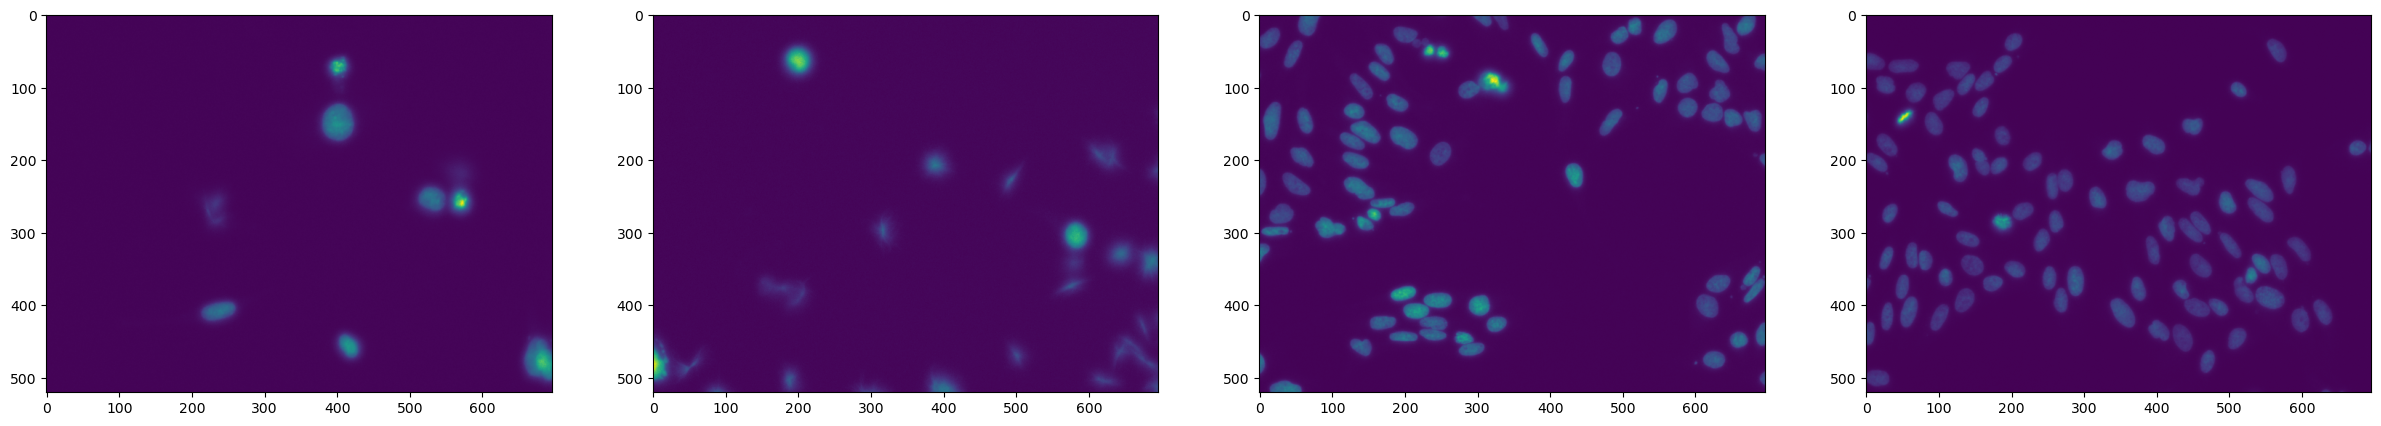

In [16]:
### Read in data
# List files
files = sorted(DATA_DIR.glob("*_w1*.tif"))[ :14]
files

### for a list of tifs
images = [ ]
for file in files:
    images.append(skimage.io.imread(file))
# skimage.io.imread_collection(files)

print(images[0].shape)
print('we have ', len(images), ' images')
print('each image has ', images[0].shape, ' pixels')

fig,ax = plt.subplots(1, 4, figsize = (30, 60) )
for i in range(0,4):
    ax[i].imshow(images[i])

## when setting up the analysis, we will use one image at a time, defined here:
img = images[3]

## Fill in for your dataset

We are working with this dataset: https://bbbc.broadinstitute.org/BBBC006. Using specifically plane 16, which is in focus, and w1 (Hoechst 33342 stain for DNA)

**Object**: Nuclei (primary). Whole-cell possible via phalloidin.

**Imaging**: Fluorescence, DAPI/Hoechst (w1) + phalloidin (w2)

**Size range**: 
- U2OS cell nuclei ~16um width and 23um length. (https://pmc.ncbi.nlm.nih.gov/articles/PMC4227890/).
- Pixel size of the camera is 6.45um and magnification is 20x, meaning each pixel is 6.45um/20 = 0.3225.  The data are binned 2x, which means each (super) pixel is 0.645um
- So we expect nuclei to be 16/.645 x 23/.645 ~ 25 x 36 pixels.

**Touching frequency**: medium. Looking at raw images shows many, but not all, objects are touching.

**Shape**: Many round, some elongated

**Signal reliability**: Using in-focus, signal is good.

**Primary failure to avoid**: oversegmenting elongated nuclei, undersegmenting touching nuclei.



In [ ]:
### 2. Pre-processing 
# i. Correct uneven background.
# contrast between objects and background is easier to identify when background is even

# ii. Denoise. 
# use median or gaussian filter to reduce noise and make contrasts more stable

# iii. Normalise intensity
# Brightness varies among images. Normalise so steps are applicable across images.

# iv. Visualise
# does it look sensible?





